# importing libraries #

In [1]:
import pandas as pd
import numpy as np


**loading dataset**

In [3]:
df=pd.read_csv("myntra_products_catalog.csv")
df.head()

,ProductID,ProductName,ProductBrand,Gender,Price (INR),NumImages,Description,PrimaryColor
0,10017413,DKNY Unisex Black & Grey Printed Medium Trolle...,DKNY,Unisex,11745,7,"Black and grey printed medium trolley bag, sec...",Black
1,10016283,EthnoVogue Women Beige & Grey Made to Measure ...,EthnoVogue,Women,5810,7,Beige & Grey made to measure kurta with churid...,Beige
2,10009781,SPYKAR Women Pink Alexa Super Skinny Fit High-...,SPYKAR,Women,899,7,Pink coloured wash 5-pocket high-rise cropped ...,Pink
3,10015921,Raymond Men Blue Self-Design Single-Breasted B...,Raymond,Men,5599,5,Blue self-design bandhgala suitBlue self-desig...,Blue
4,10017833,Parx Men Brown & Off-White Slim Fit Printed Ca...,Parx,Men,759,5,"Brown and off-white printed casual shirt, has ...",White


**exploring dataset**

In [4]:
print(df.head())

print(df.info())

print(df.describe())

print(df.shape)

print(df.columns)

   ProductID                                        ProductName ProductBrand  \
0   10017413  DKNY Unisex Black & Grey Printed Medium Trolle...         DKNY   
1   10016283  EthnoVogue Women Beige & Grey Made to Measure ...   EthnoVogue   
2   10009781  SPYKAR Women Pink Alexa Super Skinny Fit High-...       SPYKAR   
3   10015921  Raymond Men Blue Self-Design Single-Breasted B...      Raymond   
4   10017833  Parx Men Brown & Off-White Slim Fit Printed Ca...         Parx   

   Gender  Price (INR)  NumImages  \
0  Unisex        11745          7   
1   Women         5810          7   
2   Women          899          7   
3     Men         5599          5   
4     Men          759          5   

                                         Description PrimaryColor  
0  Black and grey printed medium trolley bag, sec...        Black  
1  Beige & Grey made to measure kurta with churid...        Beige  
2  Pink coloured wash 5-pocket high-rise cropped ...         Pink  
3  Blue self-design band

**checking missing values**

In [5]:
print(df.isnull().sum())

ProductID         0
ProductName       0
ProductBrand      0
Gender            0
Price (INR)       0
NumImages         0
Description       0
PrimaryColor    894
dtype: int64


**removing duplicate values**

In [11]:
df=df.drop_duplicates()
df.columns = df.columns.str.strip()
print(df.columns)

Index(['ProductID', 'ProductName', 'ProductBrand', 'Gender', 'Price (INR)',
       'NumImages', 'Description', 'PrimaryColor'],
      dtype='object')


#detecting outliers

In [12]:
# Check the data type first
print(df["Price (INR)"].dtype)

# Convert to numeric (recommended)
df["Price (INR)"] = pd.to_numeric(df["Price (INR)"], errors="coerce")

# Calculate quartiles
Q1 = df["Price (INR)"].quantile(0.25)
Q3 = df["Price (INR)"].quantile(0.75)
IQR = Q3 - Q1

# Find outliers
outliers = df[
    (df["Price (INR)"] < (Q1 - 1.5 * IQR)) |
    (df["Price (INR)"] > (Q3 + 1.5 * IQR))
]

print(outliers)

int64
       ProductID                                        ProductName  \
0       10017413  DKNY Unisex Black & Grey Printed Medium Trolle...   
1       10016283  EthnoVogue Women Beige & Grey Made to Measure ...   
3       10015921  Raymond Men Blue Self-Design Single-Breasted B...   
9       10017421                DKNY Unisex Black Large Trolley Bag   
20      10001265  Michael Kors Women Sexy Amber Eau de Parfum 100ml   
...          ...                                                ...   
12445   10266903                           Levis Men White Sneakers   
12452   10266835                           Levis Men Black Sneakers   
12459   10266871                       Levis Men Navy Blue Sneakers   
12476   10268041  Calvin Klein Jeans Men Blue Regular Fit Solid ...   
12489   10266621  Bvlgari Men Aqva Pour Homme Marine Eau de Toil...   

             ProductBrand  Gender  Price (INR)  NumImages  \
0                    DKNY  Unisex        11745          7   
1              Ethn

#counting and removing outliers

In [14]:
print("Number of outliers:", len(outliers))
df_clean = df[
    (df["Price (INR)"] >= (Q1 - 1.5 * IQR)) &
    (df["Price (INR)"] <= (Q3 + 1.5 * IQR))
]

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Number of outliers: 1167
Original Shape: (12491, 8)
Cleaned Shape: (11324, 8)


# Analysing products according to Color,Gender,Brand,Price

In [15]:
print(df_clean["ProductBrand"].value_counts().head(10))

ProductBrand
Indian Terrain          971
Pepe Jeans              340
Flying Machine          301
AURELIA                 284
U.S. Polo Assn. Kids    232
Roadster                231
W                       226
Puma                    217
GAP                     208
WROGN                   163
Name: count, dtype: int64


In [16]:
print(df_clean["Gender"].value_counts().head())

Gender
Women     4691
Men       4059
Boys      1098
Unisex     993
Girls      437
Name: count, dtype: int64


In [18]:
print(df_clean["PrimaryColor"].value_counts().head(10))

PrimaryColor
Blue       3197
 Red       1446
 Black     1368
 Green      847
 White      776
 Grey       606
 Brown      418
 Yellow     383
 Pink       372
 Beige      216
Name: count, dtype: int64


In [19]:
print(df_clean.groupby("ProductBrand")["Price (INR)"].mean().sort_values(ascending=False).head(10))

ProductBrand
Inddus               2697.500000
DKNY                 2665.000000
PUMA Motorsport      2536.500000
Qurvii               2500.000000
Allen Solly Sport    2499.000000
Geox                 2499.000000
Bohemia Crystal      2402.250000
Jn Joy               2399.000000
Healers              2392.333333
Fos Lighting         2375.000000
Name: Price (INR), dtype: float64


# **Analysing through Visualization**

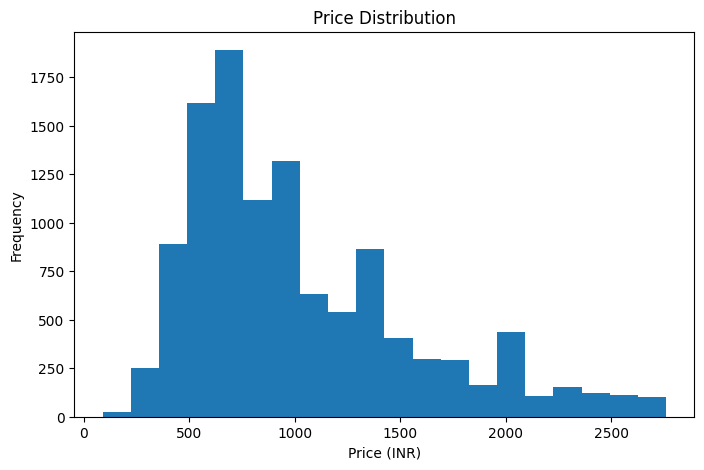

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["Price (INR)"], bins=20)
plt.title("Price Distribution")
plt.xlabel("Price (INR)")
plt.ylabel("Frequency")
plt.show()

*by gender*

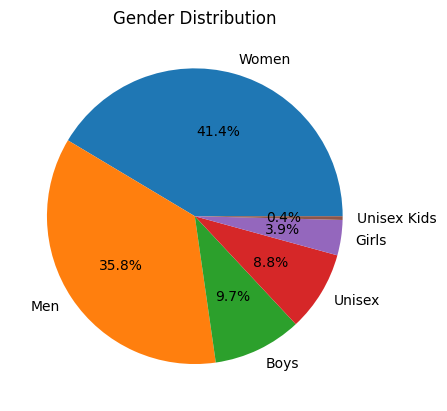

In [21]:
df_clean["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Gender Distribution")
plt.show()

*by brand*

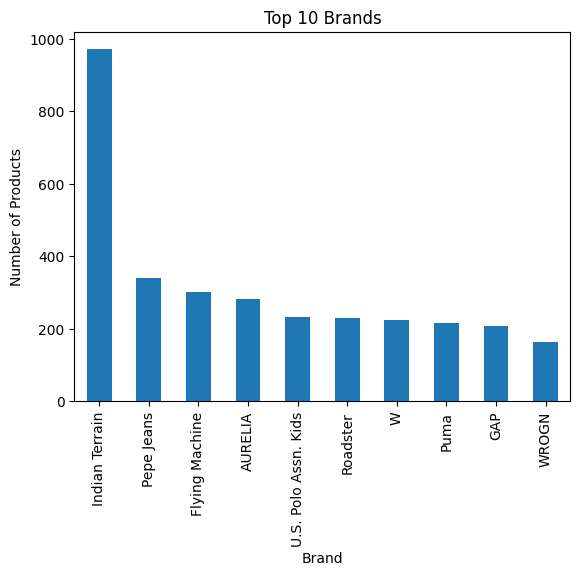

In [22]:
df_clean["ProductBrand"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.show()

#**Saving cleaned dataset**

In [23]:
df_clean.to_csv("cleaned_fashion_dataset.csv", index=False)

#**Downloading cleaned dataset**

In [24]:
from google.colab import files

files.download("cleaned_fashion_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>